In [2]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [3]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [5]:
un_training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz')

/tmp/ipykernel_4098266/955326437.py:1: DtypeWarning: Columns (6,12,13,14,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,65,66,67,68,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  un_training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz')


In [7]:
un_training_data = un_training_data[un_training_data['Assay - Qualitative Measurement'].str.contains('Positive')]

In [11]:
counts = (un_training_data
          .groupby('MHC Restriction - Name')['Epitope - Name']
          .nunique()
          .sort_values(ascending=False)
          .rename('n_unique_epitopes'))
counts = counts.reset_index()

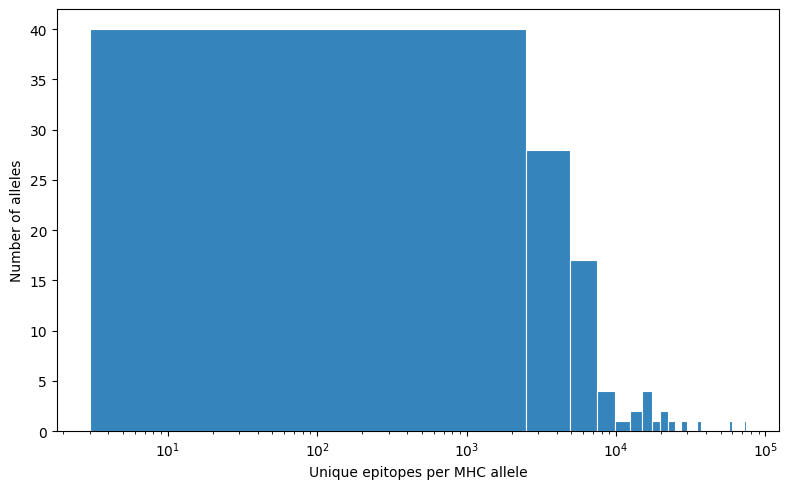

In [38]:
# filter to 8-char MHC names and grab the counts
s = counts.loc[counts['MHC Restriction - Name'].str.len() == 8, 'n_unique_epitopes'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(s, bins='auto', edgecolor='white', linewidth=0.8, alpha=0.9, ax=ax)

ax.set_xlabel('Unique epitopes per MHC allele')
ax.set_ylabel('Number of alleles')
ax.grid(False)

plt.xscale('log')
# plt.xticks([0, 1000, 10000, 100000])
plt.tight_layout()


In [40]:
counts.to_csv('../../data/HLA_eptiope_counts_data_unsupervised_train.csv', index= False)

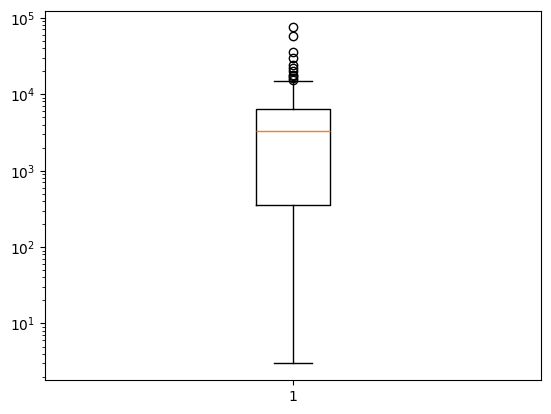

In [19]:
plt.boxplot(counts[counts['MHC Restriction - Name'].apply(len) == 8]['n_unique_epitopes'])#, bins =10)
plt.yscale('log')
plt.show()